# LOAD DATASET

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('StudentPerformanceFactors.csv')

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.shape

(6607, 20)

In [5]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

# DATASET VISUALIZATION

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

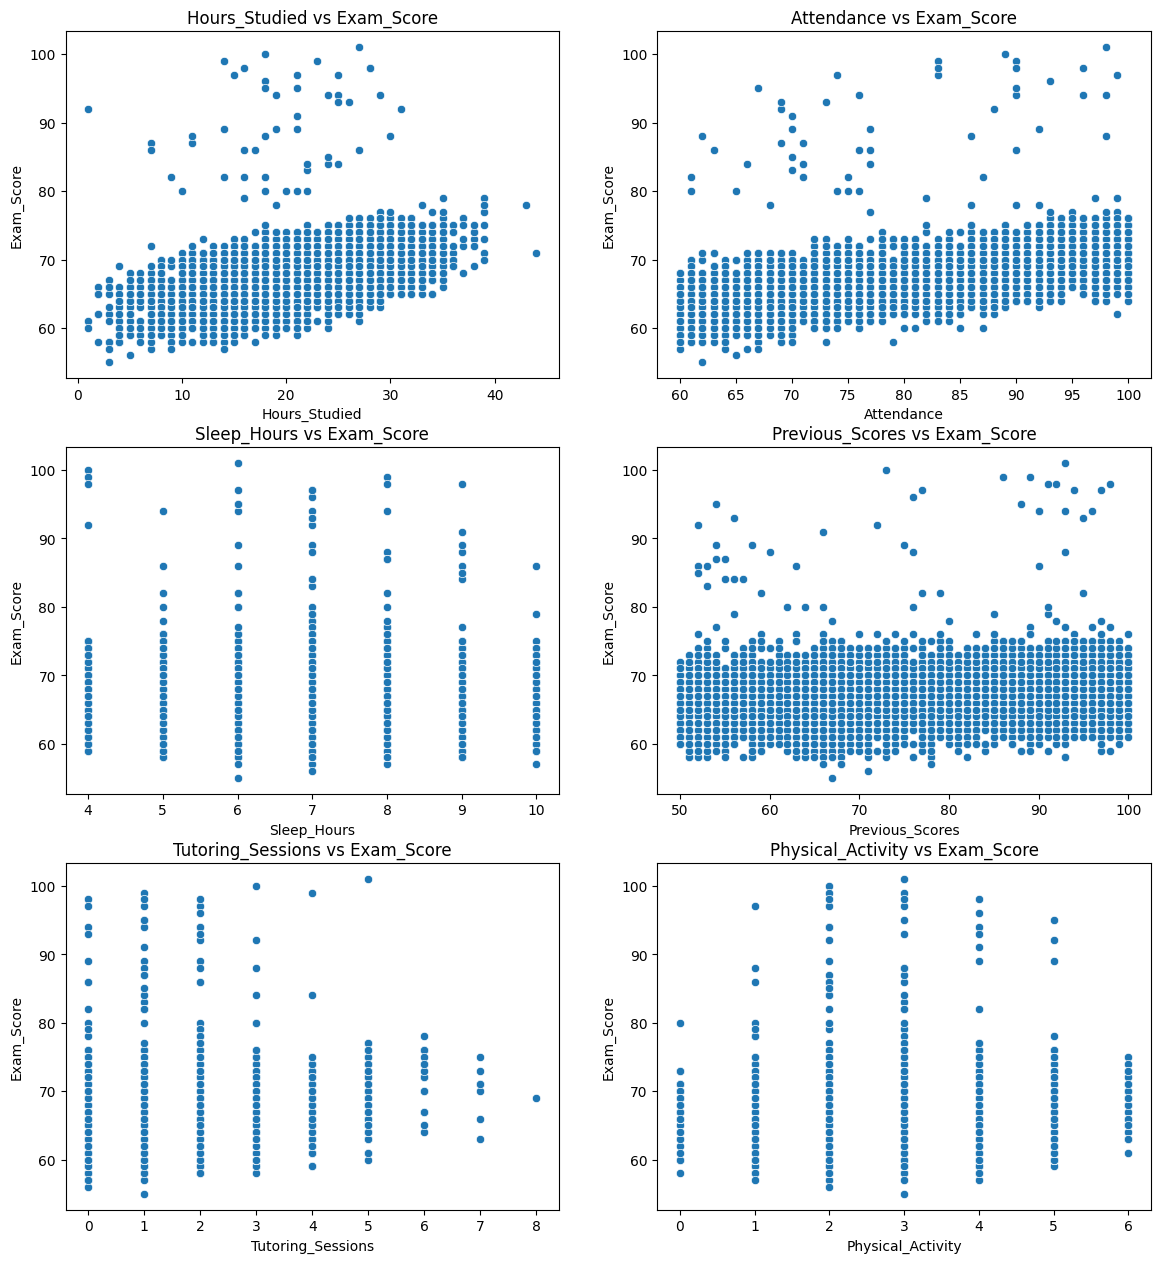

In [28]:
num_cols = df[
    [
        'Hours_Studied',
        'Attendance',
        'Sleep_Hours',
        'Previous_Scores',
        'Tutoring_Sessions',
        'Physical_Activity'
    ]
]

n_col = 2
n_row = -(-len(num_cols.columns) // n_col)


fig, axes = plt.subplots(n_row, n_col, figsize=(14, 5.1 * n_row))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.scatterplot(data=df, x=col, y='Exam_Score', ax=axes[i])
    axes[i].set_title(f'{col} vs Exam_Score')

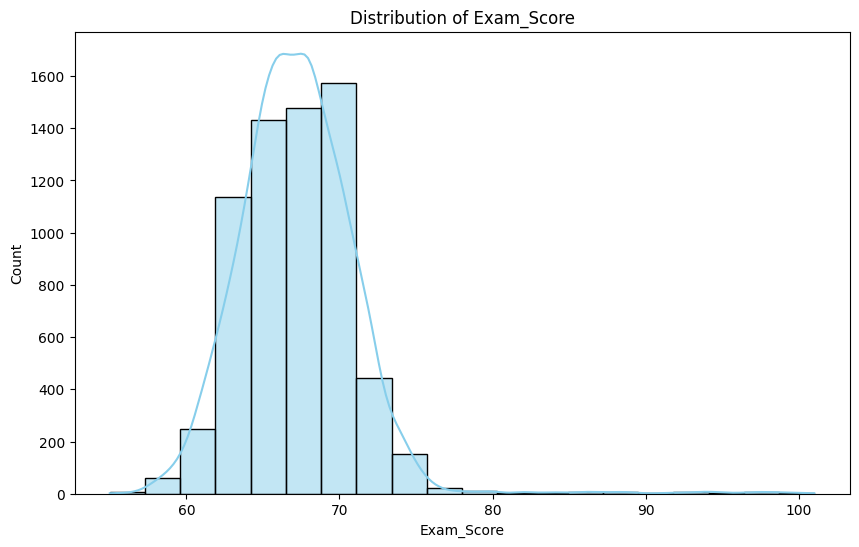

In [36]:
# Histogram of Exam_Score
plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Exam_Score')
plt.xlabel('Exam_Score')
plt.show()

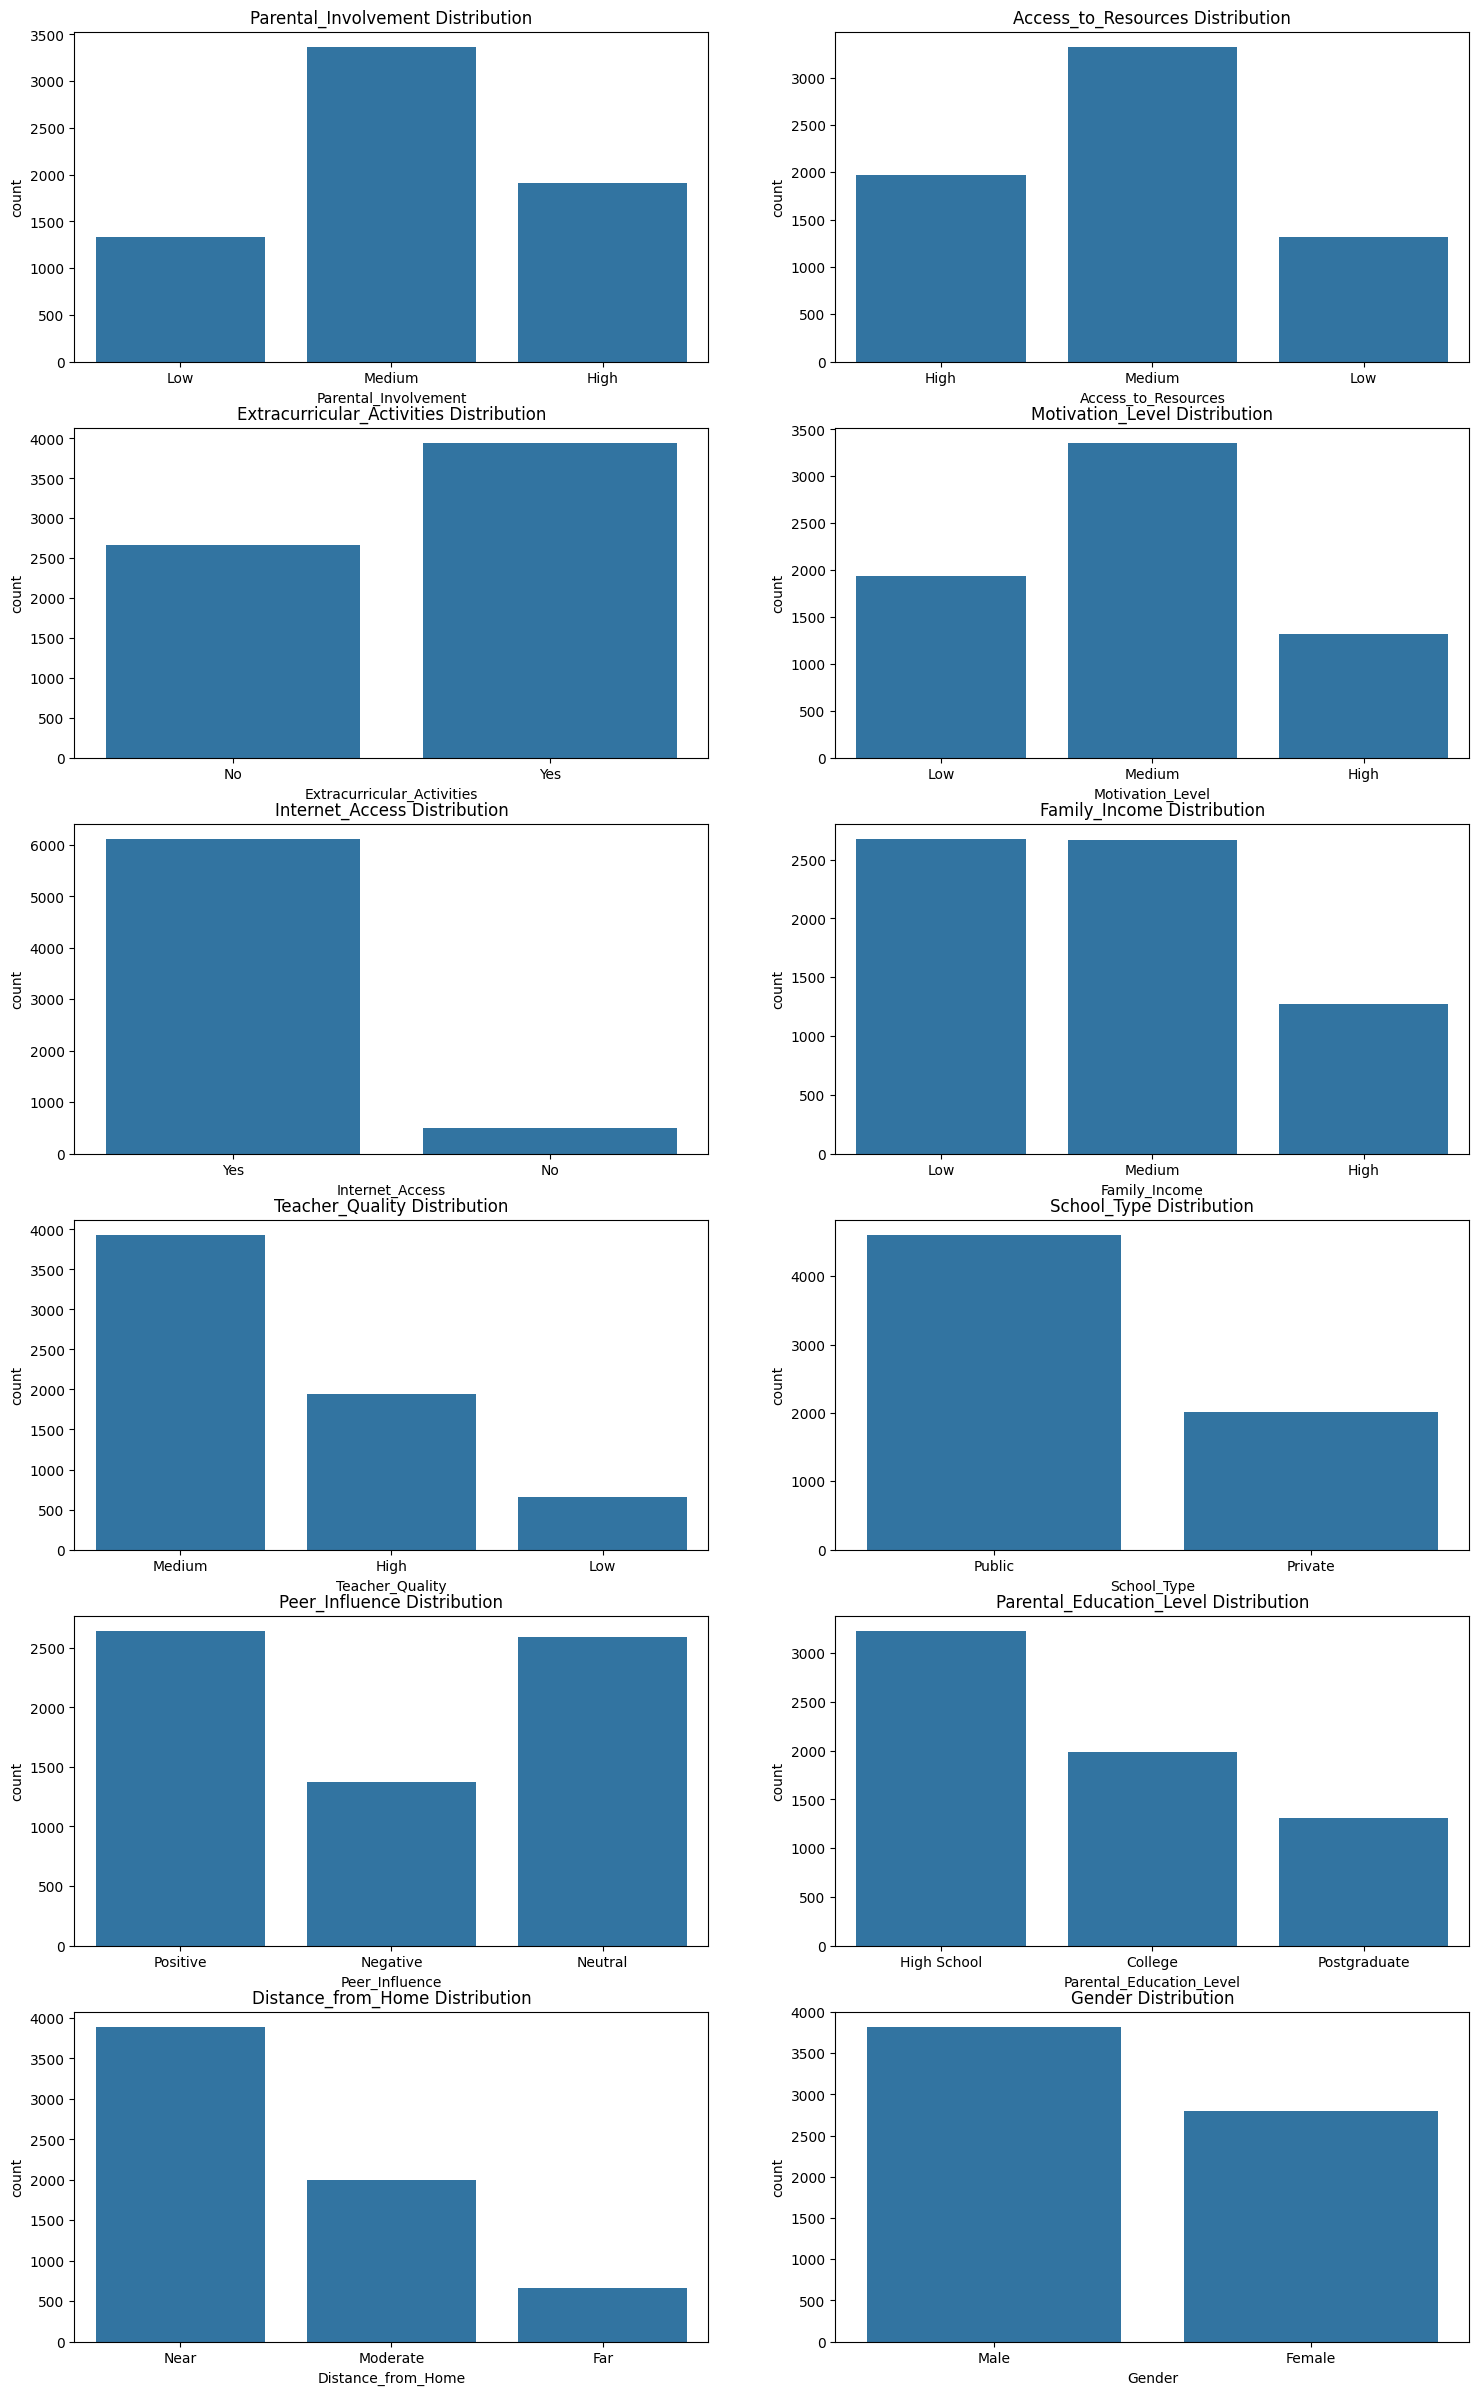

In [42]:
categ_cols = df[
    [
        'Parental_Involvement',
        'Access_to_Resources',
        'Extracurricular_Activities',
        'Motivation_Level',
        'Internet_Access',
        'Family_Income',
        'Teacher_Quality',
        'School_Type',
        'Peer_Influence',
        'Parental_Education_Level',
        'Distance_from_Home',
        'Gender'
    ]
]

n_col = 2
n_row = -(-len(categ_cols.columns) // n_col)


fig, axes = plt.subplots(n_row, n_col, figsize=(18, 5 * n_row))
axes = axes.flatten()

for i, col in enumerate(categ_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')

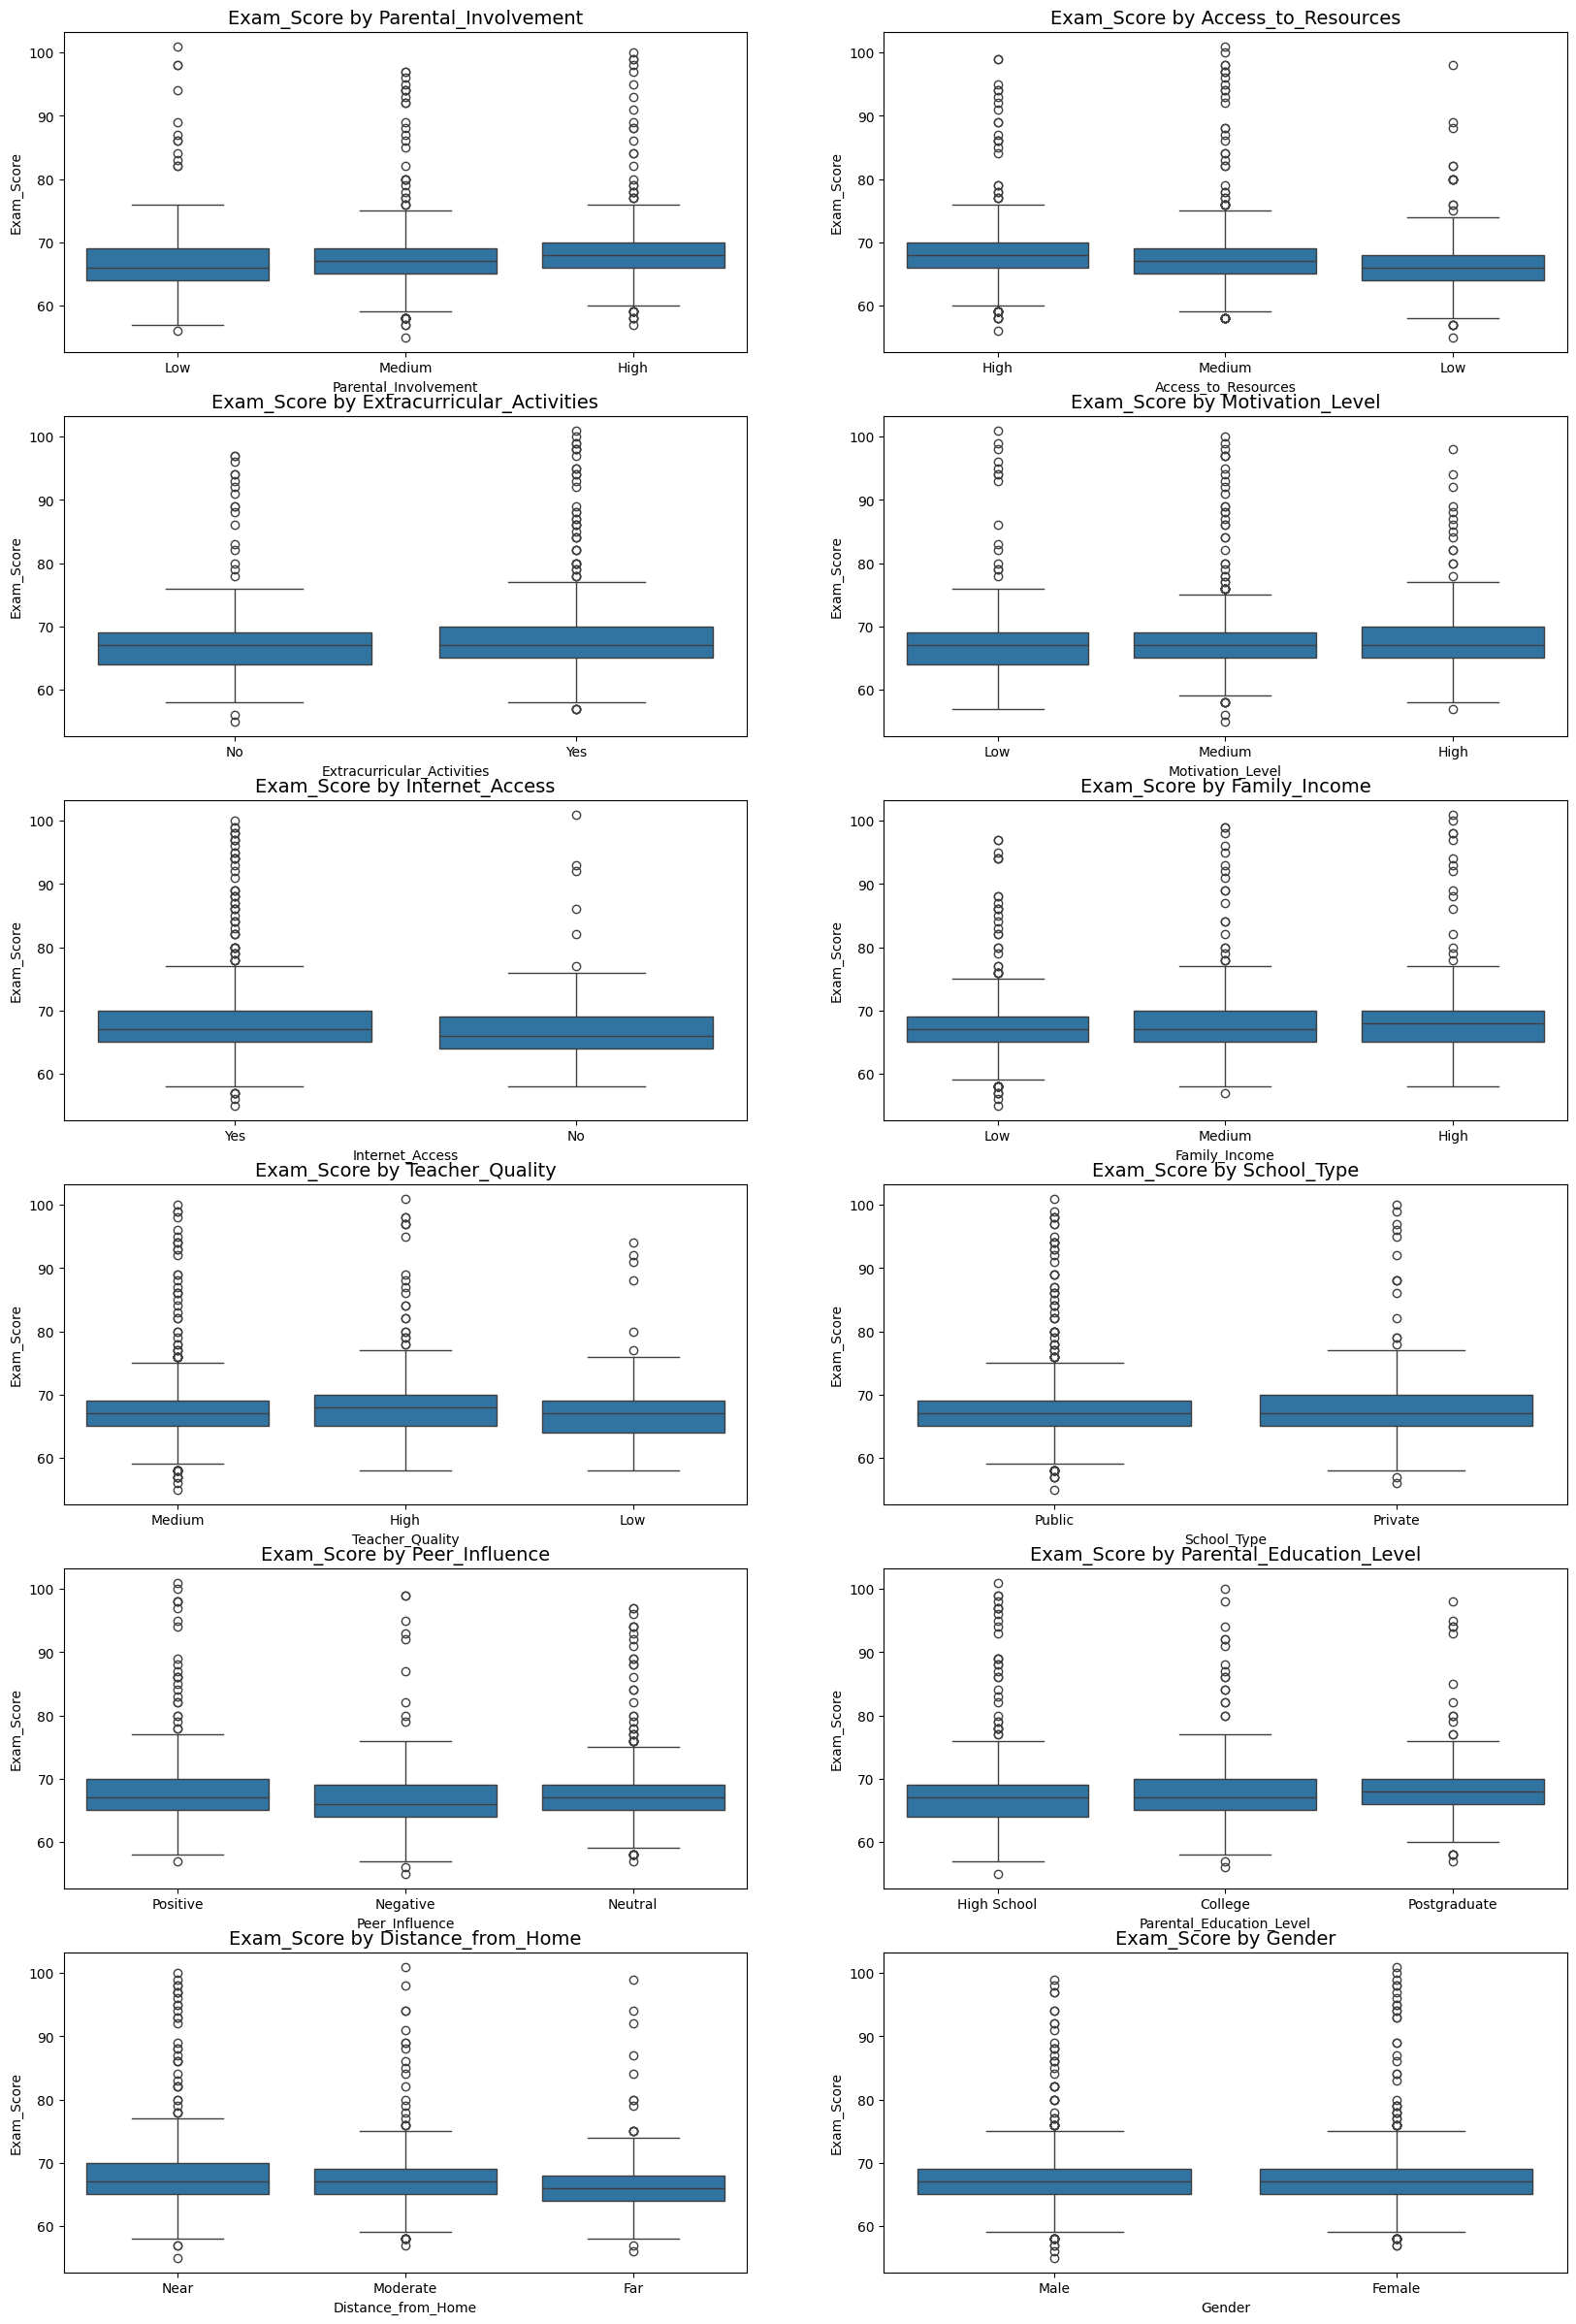

In [47]:
n_col = 2
n_row = -(-len(categ_cols.columns) // n_col)


fig, axes = plt.subplots(n_row, n_col, figsize=(20, 5 * n_row))
axes = axes.flatten()

for i, col in enumerate(categ_cols):
    sns.boxplot(data=df, x=col, y='Exam_Score', ax=axes[i])
    axes[i].set_title(f'Exam_Score by {col}', fontsize=14)

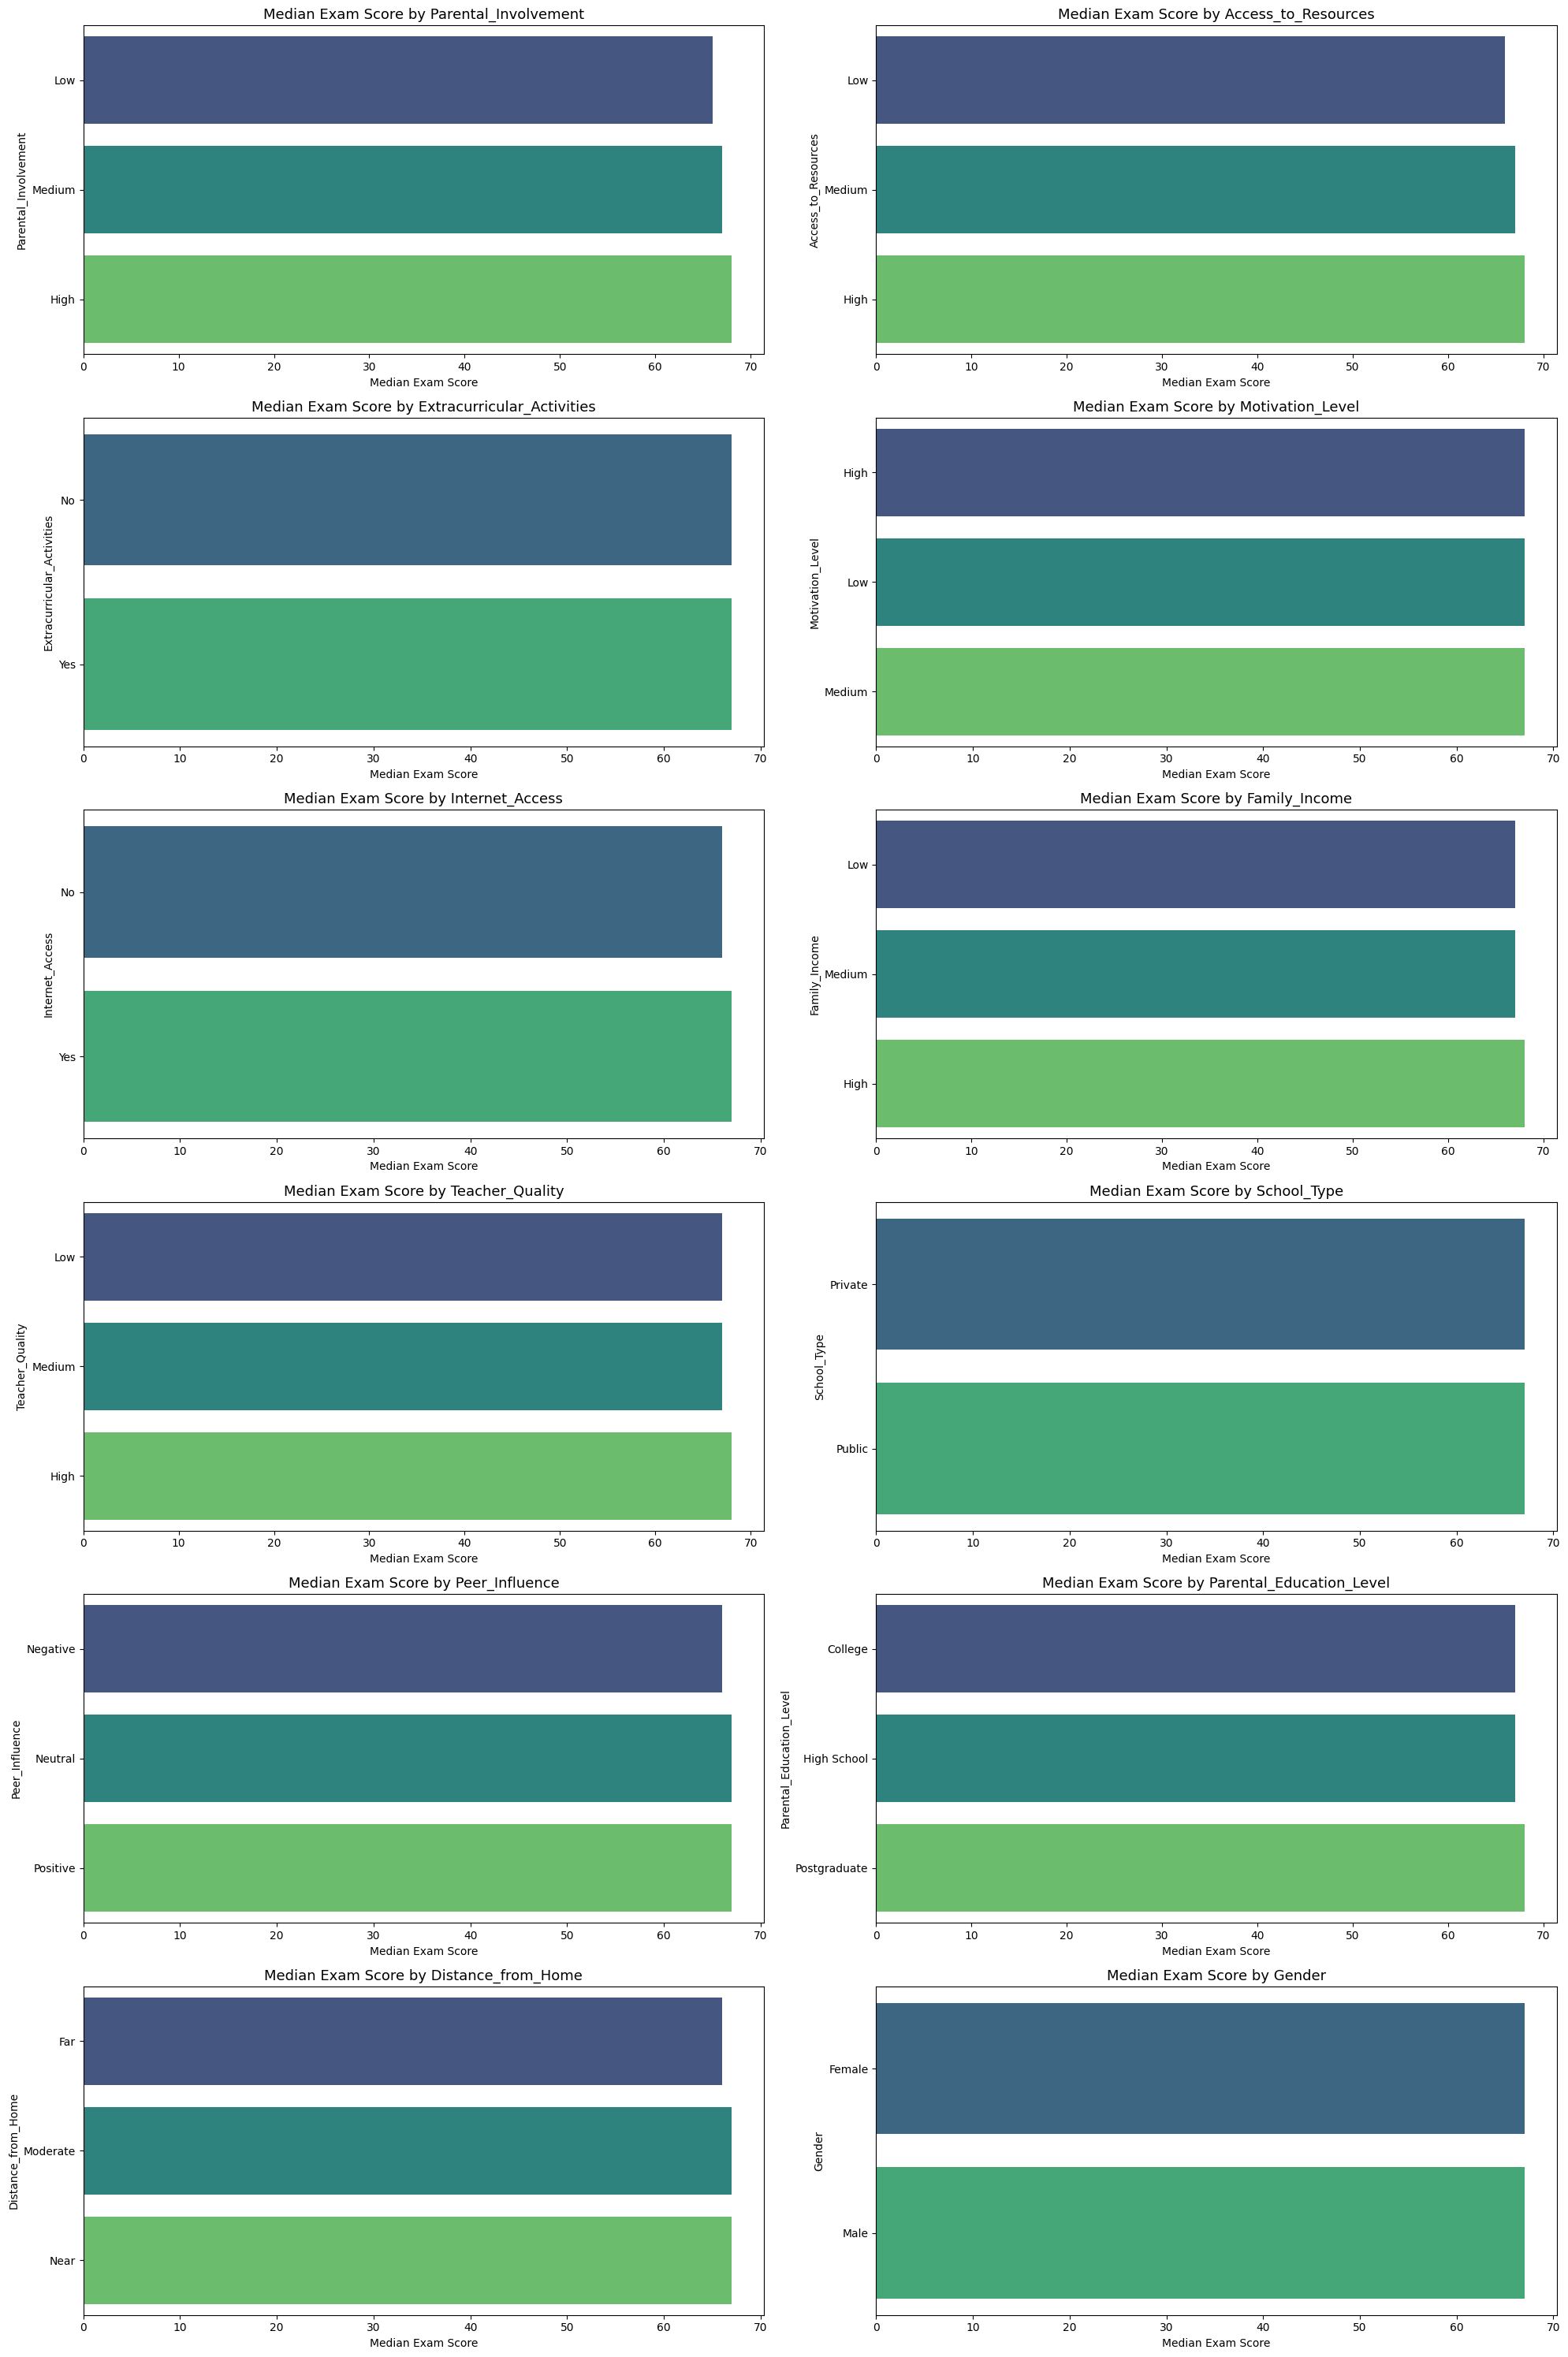

In [52]:
n_col = 2
n_row = -(-len(categ_cols.columns) // n_col)

fig, axes = plt.subplots(
    n_row,
    n_col,
    figsize=(20, 5 * n_row)
)

axes = axes.flatten()

for i, col in enumerate(categ_cols):
    median_scores = ( df.groupby(col)['Exam_Score'].median().sort_values())

    sns.barplot(x=median_scores.values,y=median_scores.index,hue=median_scores.index,palette='viridis',legend=False,ax=axes[i])

    axes[i].set_title(f'Median Exam Score by {col}',fontsize=13,)

    axes[i].set_xlabel('Median Exam Score')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# PROCESSING I